# Autoencoder & VAE Walkthrough
## Unit 4, Day 9 - Compress, Learn, Create

In this walkthrough, we'll build two models:

1. **A Simple Autoencoder** - Compress handwritten digits into a tiny embedding, then reconstruct them
2. **A Variational Autoencoder (VAE)** - Same idea, but now we can *generate brand new digits*

We'll use the MNIST dataset (28x28 pixel handwritten digits) because it's simple enough to see clear results quickly.

---

## Setup & Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.1


### Load MNIST

Each image is 28x28 pixels = **784 numbers**. We'll flatten them into a single vector and normalize pixel values to 0-1.

In [3]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and flatten to vectors
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print(f"Training images: {x_train_flat.shape}")
print(f"Test images: {x_test_flat.shape}")
print(f"Each image: {x_train_flat.shape[1]} pixels (28 x 28 flattened)")

Training images: (60000, 784)
Test images: (10000, 784)
Each image: 784 pixels (28 x 28 flattened)


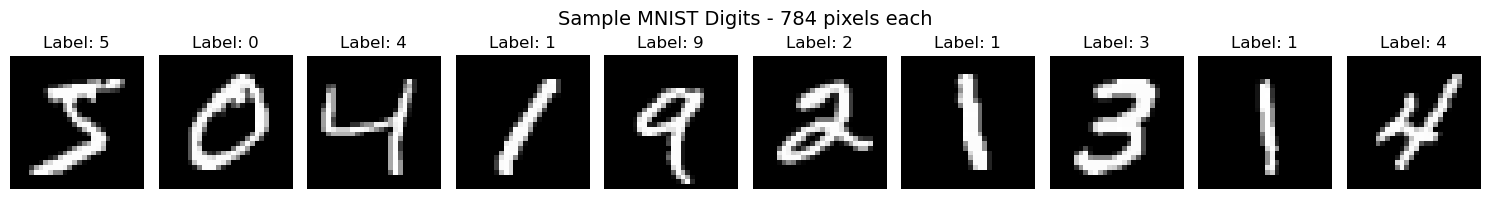

In [4]:
# Let's see what we're working with
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.suptitle("Sample MNIST Digits - 784 pixels each", fontsize=14)
plt.tight_layout()
plt.show()

---

# Part 1: Simple Autoencoder

## The Goal

Take 784 numbers (pixels) → compress to just **32 numbers** (the embedding) → reconstruct back to 784 numbers.

```
784 → [Encoder] → 32 → [Decoder] → 784
```

The network has to figure out how to squeeze an entire digit into just 32 numbers. That forces it to learn **what actually matters** about each digit.

---

## Building the Autoencoder

The architecture is straightforward - two halves:
- **Encoder**: 784 → 128 → 32 (compress)
- **Decoder**: 32 → 128 → 784 (reconstruct)

The middle layer (32 neurons) is the **bottleneck** - our latent space.

In [5]:
# === THE ENCODER ===
# Takes 784 pixels and compresses to 32 numbers

encoder_input = layers.Input(shape=(784,), name="encoder_input")
x = layers.Dense(128, activation="relu", name="encoder_hidden")(encoder_input)
latent = layers.Dense(32, activation="relu", name="latent_space")(x)

encoder = Model(encoder_input, latent, name="encoder")

print("=== ENCODER ===")
encoder.summary()

=== ENCODER ===


2026-02-23 22:32:27.620623: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-23 22:32:27.620656: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-23 22:32:27.620666: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-02-23 22:32:27.620878: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 22:32:27.620903: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_hidden (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,608 (408.62 KB)

 Trainable params: 104,608 (408.62 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# === THE DECODER ===
# Takes 32 numbers and reconstructs back to 784 pixels

decoder_input = layers.Input(shape=(32,), name="decoder_input")
x = layers.Dense(128, activation="relu", name="decoder_hidden")(decoder_input)
decoder_output = layers.Dense(784, activation="sigmoid", name="decoder_output")(x)

decoder = Model(decoder_input, decoder_output, name="decoder")

print("=== DECODER ===")
decoder.summary()

=== DECODER ===


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_hidden (Dense)          │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# === FULL AUTOENCODER ===
# Chain them together: input → encoder → decoder → output

autoencoder_input = layers.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input, decoded, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")

print("=== FULL AUTOENCODER ===")
print(f"Input:  784 pixels")
print(f"Latent:  32 numbers  ← this is the bottleneck!")
print(f"Output: 784 pixels")
print(f"\nCompression ratio: 784 → 32 = {784/32:.0f}x compression")

=== FULL AUTOENCODER ===
Input:  784 pixels
Latent:  32 numbers  ← this is the bottleneck!
Output: 784 pixels

Compression ratio: 784 → 32 = 24x compression


## Training

Here's the key insight: **the input IS the target**. We're training the network to reconstruct its own input after squeezing it through the bottleneck.

Loss = how different is the output from the input? (Mean Squared Error)

In [8]:
# Train - notice x_train_flat is both the input AND the target!
history = autoencoder.fit(
    x_train_flat, x_train_flat,  # input = target
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)

Epoch 1/20


2026-02-23 22:32:46.666613: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0541 - val_loss: 0.0303
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0250 - val_loss: 0.0209
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0212 - val_loss: 0.0229
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0437 - val_loss: 0.0938
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0972 - val_loss: 0.0988
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1005 - val_loss: 0.1019
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1019 - val_loss: 0.1026
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1021 - val_loss: 0.1033
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1025 - val_loss: 0.1024
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1019 - val_loss: 0.1024
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1017 - val_loss: 0.1031
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.

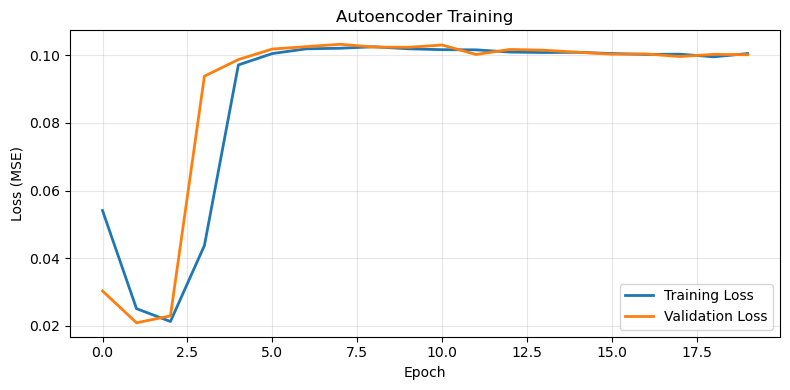

In [9]:
# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results: Original vs Reconstructed

Let's see how well the autoencoder can reconstruct digits after compressing them from 784 numbers down to just 32.

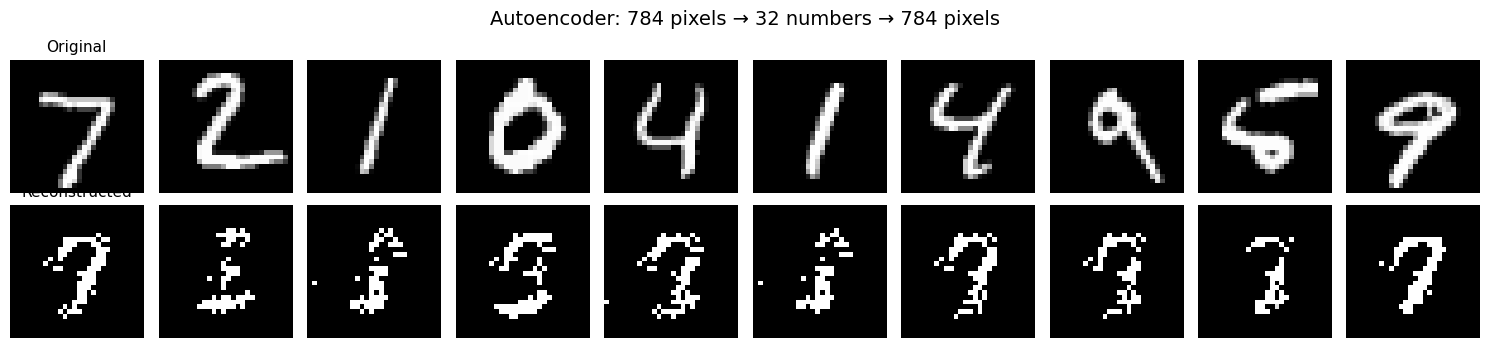

Not perfect, but pretty good for 24x compression!


In [10]:
# Reconstruct test images
reconstructed = autoencoder.predict(x_test_flat[:10], verbose=0)

# Show original vs reconstructed
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))

for i in range(10):
    # Original
    axes[0][i].imshow(x_test[i], cmap='gray')
    axes[0][i].axis('off')
    if i == 0:
        axes[0][i].set_title('Original', fontsize=11)
    
    # Reconstructed
    axes[1][i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1][i].axis('off')
    if i == 0:
        axes[1][i].set_title('Reconstructed', fontsize=11)

plt.suptitle('Autoencoder: 784 pixels → 32 numbers → 784 pixels', fontsize=14)
plt.tight_layout()
plt.show()

print("Not perfect, but pretty good for 24x compression!")

## The Embeddings (Latent Space)

Now let's look at what the encoder actually learned. Each digit gets compressed into 32 numbers - its **embedding**.

If the encoder learned well, similar digits should have similar embeddings. Let's visualize this by reducing those 32 dimensions down to 2 using t-SNE.

In [11]:
from sklearn.manifold import TSNE

# Get embeddings for a subset of test images
n_samples = 3000
embeddings = encoder.predict(x_test_flat[:n_samples], verbose=0)

print(f"Each digit compressed to: {embeddings.shape[1]} numbers")
print(f"Example embedding (first 10 values): {np.round(embeddings[0][:10], 2)}")

# Reduce 32D → 2D for visualization
print("\nRunning t-SNE to visualize 32D embeddings in 2D...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

Each digit compressed to: 32 numbers
Example embedding (first 10 values): [ -27.51   41.42  261.1   832.28  -50.27 1252.75  -24.56  911.17  284.2
   39.82]

Running t-SNE to visualize 32D embeddings in 2D...


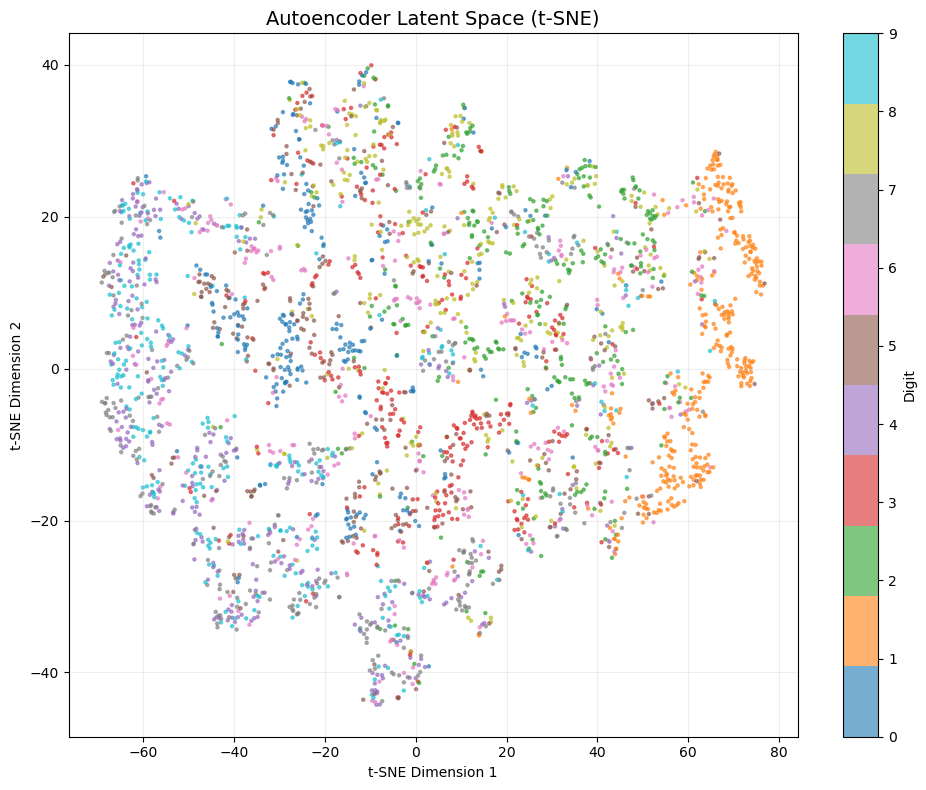

Notice: Similar digits cluster together!
The encoder learned to group similar things without being told which digits are which.


In [12]:
# Visualize the latent space - each color is a different digit
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=y_test[:n_samples], cmap='tab10',
    s=5, alpha=0.6
)
plt.colorbar(scatter, label='Digit')
plt.title('Autoencoder Latent Space (t-SNE)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Notice: Similar digits cluster together!")
print("The encoder learned to group similar things without being told which digits are which.")

## Key Takeaway from Part 1

The autoencoder learned to:
1. **Compress** 784 pixels into just 32 numbers
2. **Reconstruct** the original image from those 32 numbers
3. **Organize** similar digits near each other in the latent space - without any labels!

Those 32 numbers (the embedding) capture the **essence** of each digit. This is incredibly useful for:
- Similarity search (find images that look alike)
- Anomaly detection (things that don't reconstruct well are unusual)
- Feature extraction (feed embeddings into another model)

**But there's a problem:** The latent space has gaps and isn't smooth. If we pick a random point in that space and decode it, we might get garbage. The autoencoder only knows how to decode points it's seen before.

**That's where VAEs come in.**

---

# Part 2: Variational Autoencoder (VAE)

## The Key Difference

Instead of encoding to a **fixed point** in latent space, the VAE encoder outputs a **probability distribution** (mean + variance).

```
Autoencoder:  784 → [Encoder] → [32 fixed numbers] → [Decoder] → 784

VAE:          784 → [Encoder] → [mean, variance] → sample → [Decoder] → 784
```

This small change has a huge consequence: the latent space becomes **smooth and continuous**, which means we can sample from it to generate new data.

---

## Building the VAE

### The Sampling Layer

This is the magic piece. Instead of a fixed bottleneck, we:
1. Encoder outputs `z_mean` and `z_log_var` (mean and log-variance)
2. We **sample** from this distribution: `z = mean + exp(0.5 * log_var) * random_noise`

The random noise is what makes it generative - every forward pass produces a slightly different encoding.

In [13]:
# The Sampling Layer - this is the key difference from a regular autoencoder

class Sampling(layers.Layer):
    """Sample from a normal distribution parameterized by mean and log-variance."""
    
    def call(self, inputs):
        z_mean, z_log_var = inputs
        # Generate random noise
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        # Reparameterization trick: z = mean + std * noise
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

print("Sampling layer defined!")
print("This is the reparameterization trick:")
print("  z = z_mean + exp(0.5 * z_log_var) * epsilon")
print("  where epsilon is random noise from N(0, 1)")

Sampling layer defined!
This is the reparameterization trick:
  z = z_mean + exp(0.5 * z_log_var) * epsilon
  where epsilon is random noise from N(0, 1)


In [14]:
# === VAE ENCODER ===
# Same structure, but outputs mean and variance instead of a fixed vector

latent_dim = 2  # Using 2D so we can visualize directly!

vae_encoder_input = layers.Input(shape=(784,), name="vae_input")
x = layers.Dense(256, activation="relu", name="vae_enc_h1")(vae_encoder_input)
x = layers.Dense(128, activation="relu", name="vae_enc_h2")(x)

# Instead of one output, we get TWO: mean and log-variance
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sample from the distribution
z = Sampling()([z_mean, z_log_var])

vae_encoder = Model(vae_encoder_input, [z_mean, z_log_var, z], name="vae_encoder")

print("=== VAE ENCODER ===")
print(f"Input:  784 pixels")
print(f"Output: z_mean ({latent_dim}D) + z_log_var ({latent_dim}D) + sampled z ({latent_dim}D)")
print(f"\nUsing {latent_dim}D latent space so we can visualize it directly!")

=== VAE ENCODER ===
Input:  784 pixels
Output: z_mean (2D) + z_log_var (2D) + sampled z (2D)

Using 2D latent space so we can visualize it directly!


In [15]:
# === VAE DECODER ===
# Takes a sampled point from latent space and reconstructs an image

vae_decoder_input = layers.Input(shape=(latent_dim,), name="vae_dec_input")
x = layers.Dense(128, activation="relu", name="vae_dec_h1")(vae_decoder_input)
x = layers.Dense(256, activation="relu", name="vae_dec_h2")(x)
vae_decoder_output = layers.Dense(784, activation="sigmoid", name="vae_dec_output")(x)

vae_decoder = Model(vae_decoder_input, vae_decoder_output, name="vae_decoder")

print("=== VAE DECODER ===")
print(f"Input:  {latent_dim} numbers from latent space")
print(f"Output: 784 pixels")

=== VAE DECODER ===
Input:  2 numbers from latent space
Output: 784 pixels


## VAE Loss Function

The VAE loss has **two parts**:

1. **Reconstruction Loss** - How well can it rebuild the input? (same as autoencoder)
2. **KL Divergence** - How close is the learned distribution to a standard normal? (this is what makes the latent space smooth)

```
Total Loss = Reconstruction Loss + KL Divergence
```

The KL term acts like a regularizer - it pushes the latent space to be organized and continuous, with no gaps.

In [16]:
# === FULL VAE MODEL ===
# We use a custom model class to define the special VAE loss

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]
    
    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Forward pass
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            # Part 1: Reconstruction loss (how well did we rebuild?)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=-1
                )
            )
            
            # Part 2: KL divergence (how organized is the latent space?)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=-1
                )
            )
            
            # Total loss = both parts
            total_loss = reconstruction_loss + kl_loss
        
        # Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        # Track metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Build and compile
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam())

print("VAE built!")
print("Loss = Reconstruction Loss + KL Divergence")

VAE built!
Loss = Reconstruction Loss + KL Divergence


In [17]:
# Train the VAE
vae_history = vae.fit(
    x_train_flat,
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - kl_loss: 1.2468 - reconstruction_loss: 35.6858 - total_loss: 36.9326
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan                                 
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - kl_loss: nan - reconstruction_loss: nan - total_loss: nan
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step

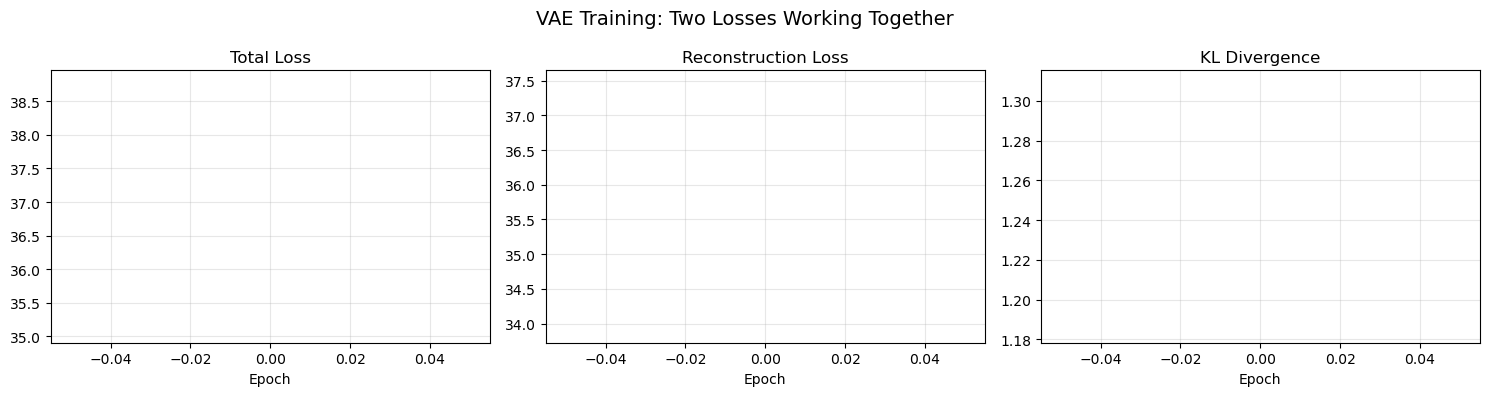

In [18]:
# Training curves - now we can see both loss components
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_history.history['total_loss'], linewidth=2, color='#C65D00')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(vae_history.history['reconstruction_loss'], linewidth=2, color='#8B7355')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

axes[2].plot(vae_history.history['kl_loss'], linewidth=2, color='#5D4E37')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('VAE Training: Two Losses Working Together', fontsize=14)
plt.tight_layout()
plt.show()

## VAE Reconstructions

Let's see how well the VAE reconstructs digits. Remember - it's working with only **2 dimensions** of latent space (compared to the autoencoder's 32), so we expect it to be blurrier.

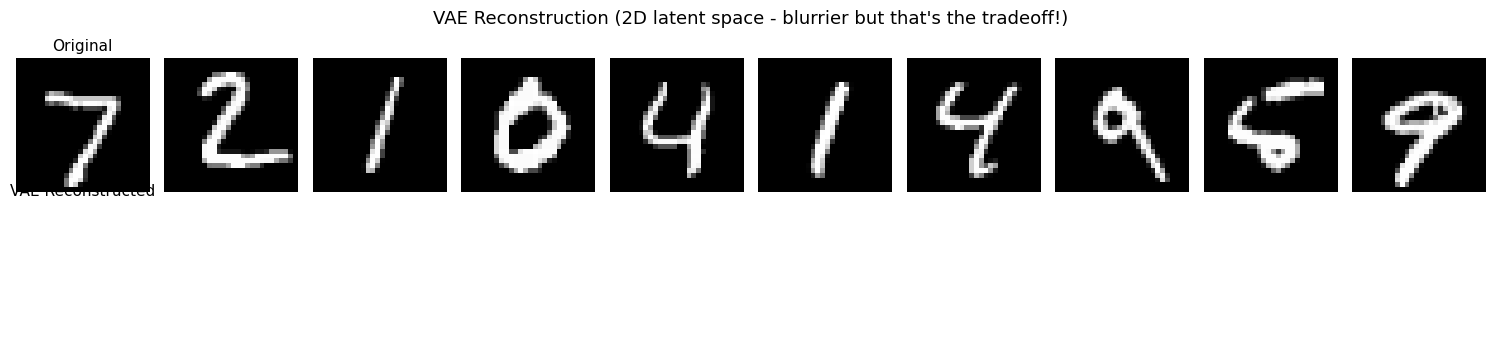

In [19]:
# VAE reconstructions
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(x_test_flat[:10], verbose=0)
vae_reconstructed = vae_decoder.predict(z_test, verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))

for i in range(10):
    axes[0][i].imshow(x_test[i], cmap='gray')
    axes[0][i].axis('off')
    if i == 0:
        axes[0][i].set_title('Original', fontsize=11)
    
    axes[1][i].imshow(vae_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1][i].axis('off')
    if i == 0:
        axes[1][i].set_title('VAE Reconstructed', fontsize=11)

plt.suptitle('VAE Reconstruction (2D latent space - blurrier but that\'s the tradeoff!)', fontsize=13)
plt.tight_layout()
plt.show()

## Visualizing the VAE Latent Space

Since we used a 2D latent space, we can visualize it **directly** - no t-SNE needed! Each point is where the encoder placed a digit.

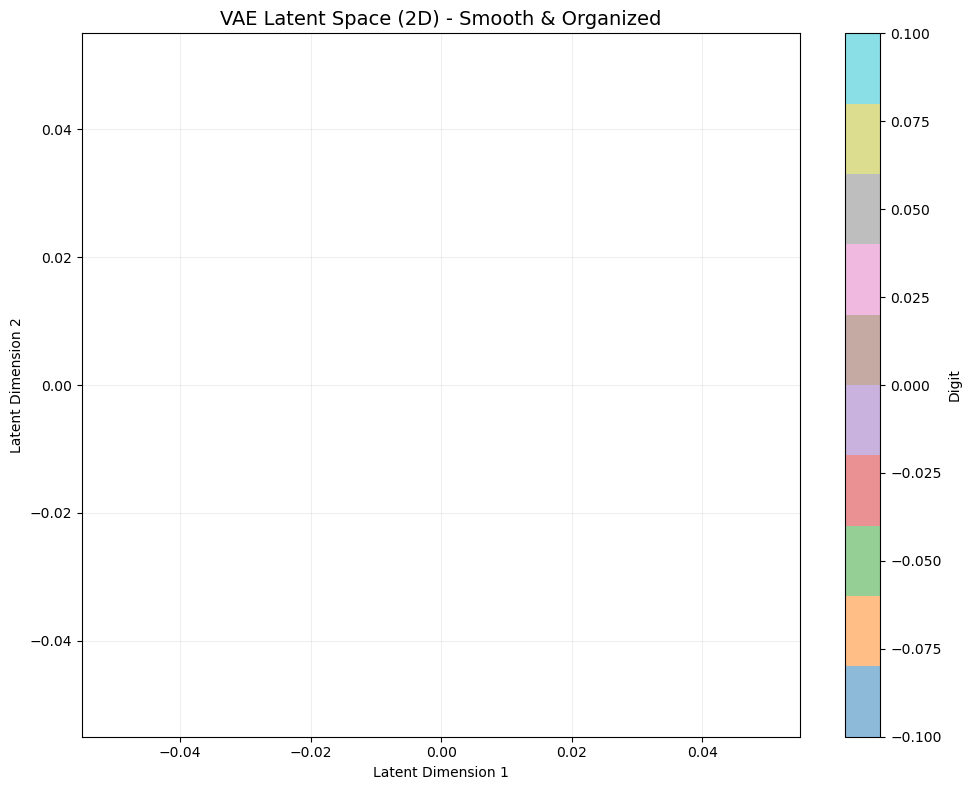

Notice how the latent space is smooth and continuous.
Digits cluster together, and nearby clusters are visually similar digits.
There are NO big gaps - this means we can sample from anywhere!


In [20]:
# Encode all test images into 2D latent space
z_mean_all, _, _ = vae_encoder.predict(x_test_flat, verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean_all[:, 0], z_mean_all[:, 1],
    c=y_test, cmap='tab10',
    s=5, alpha=0.5
)
plt.colorbar(scatter, label='Digit')
plt.title('VAE Latent Space (2D) - Smooth & Organized', fontsize=14)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Notice how the latent space is smooth and continuous.")
print("Digits cluster together, and nearby clusters are visually similar digits.")
print("There are NO big gaps - this means we can sample from anywhere!")

## The Magic: Generating New Digits

This is what makes VAEs special. We can:
1. Pick random points in latent space
2. Feed them through the decoder ONLY
3. Get brand new digits that never existed!

We'll create a grid of points across the latent space and see what the decoder generates at each location.

In [ ]:
# Generate a grid of digits across the latent space
n = 20  # 20x20 grid
figure = np.zeros((28 * n, 28 * n))

# Create a grid of points in latent space
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        # Pick a point in latent space
        z_sample = np.array([[xi, yi]])
        # Decode it into an image
        x_decoded = vae_decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(28, 28)
        figure[i * 28 : (i + 1) * 28, j * 28 : (j + 1) * 28] = digit

plt.figure(figsize=(12, 12))
plt.imshow(figure, cmap="gray")
plt.title("Generated Digits Across Latent Space", fontsize=16)
plt.xlabel("Latent Dimension 1 →", fontsize=12)
plt.ylabel("← Latent Dimension 2", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Every single digit in this grid was GENERATED - none of them exist in the training data!")
print("Notice how digits smoothly transform as you move across the latent space.")

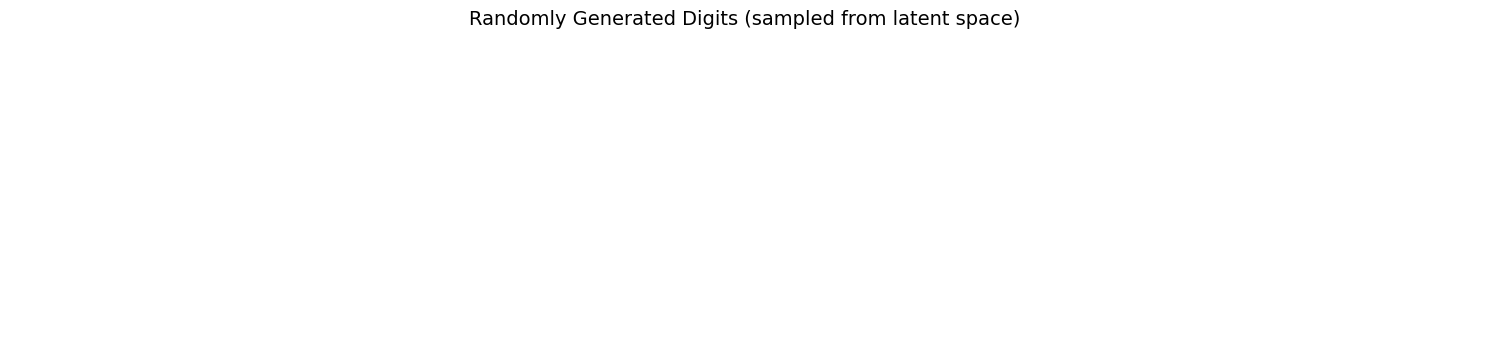

These digits were created by sampling random points and decoding them.
None of these existed in the training data!


In [21]:
# Generate some random digits
n_generate = 20
random_latent_points = np.random.normal(size=(n_generate, latent_dim))
generated_images = vae_decoder.predict(random_latent_points, verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for i in range(n_generate):
    row = i // 10
    col = i % 10
    axes[row][col].imshow(generated_images[i].reshape(28, 28), cmap='gray')
    axes[row][col].axis('off')

plt.suptitle('Randomly Generated Digits (sampled from latent space)', fontsize=14)
plt.tight_layout()
plt.show()

print("These digits were created by sampling random points and decoding them.")
print("None of these existed in the training data!")

## Latent Space Interpolation

One more cool trick: we can smoothly morph between two digits by walking through latent space.

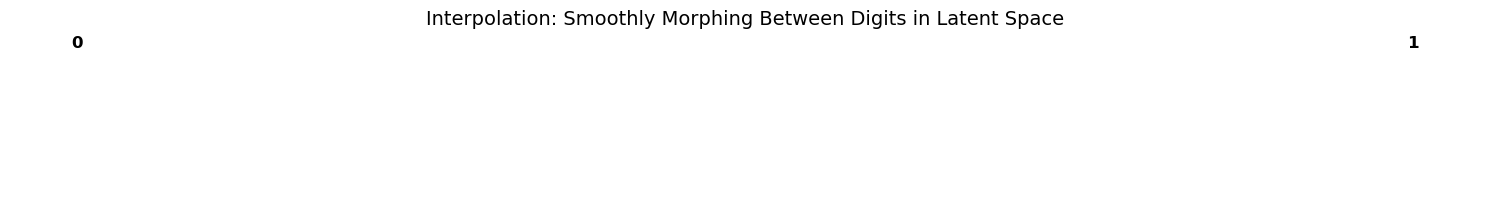

The smooth transition proves the latent space is continuous - no gaps!


In [22]:
# Pick two digits and interpolate between them in latent space

# Find a 0 and a 1 in the test set
idx_0 = np.where(y_test == 0)[0][0]
idx_1 = np.where(y_test == 1)[0][0]

# Get their latent representations
z_0, _, _ = vae_encoder.predict(x_test_flat[idx_0:idx_0+1], verbose=0)
z_1, _, _ = vae_encoder.predict(x_test_flat[idx_1:idx_1+1], verbose=0)

# Create 10 steps between them
n_steps = 10
alphas = np.linspace(0, 1, n_steps)
interpolated = np.array([z_0[0] * (1 - a) + z_1[0] * a for a in alphas])

# Decode each step
decoded_steps = vae_decoder.predict(interpolated, verbose=0)

fig, axes = plt.subplots(1, n_steps, figsize=(15, 2))
for i in range(n_steps):
    axes[i].imshow(decoded_steps[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    if i == 0:
        axes[i].set_title('0', fontsize=12, fontweight='bold')
    elif i == n_steps - 1:
        axes[i].set_title('1', fontsize=12, fontweight='bold')

plt.suptitle('Interpolation: Smoothly Morphing Between Digits in Latent Space', fontsize=14)
plt.tight_layout()
plt.show()

print("The smooth transition proves the latent space is continuous - no gaps!")

---

# Key Takeaways

| | Autoencoder | VAE |
|---|---|---|
| **Latent space** | Fixed points (can have gaps) | Smooth probability distributions |
| **Can generate?** | Not really - gaps cause garbage | Yes! Sample anywhere in latent space |
| **Reconstruction** | Sharper (more capacity) | Blurrier (tradeoff for smoothness) |
| **Loss function** | Just reconstruction | Reconstruction + KL divergence |
| **Best for** | Compression, denoising, embeddings | Generation, interpolation, creative AI |

### The Bottom Line

- **Autoencoders** are great for learning compressed representations (embeddings) of data
- **VAEs** add the ability to **generate** by making the latent space smooth and continuous
- In modern AI, VAEs are used as the **compression backbone** inside larger models (like Stable Diffusion)
- The concepts of latent space, encoding, and decoding are fundamental to understanding all generative AI